In [2]:
!pip install --pre scapy[basic]
!pip install pythonping

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.6 MB/s eta 0:00:00


info of host: 
IP:  34.122.1.204
lat:  41.2619
lon:  -95.8608
Organization:  Google Cloud (us-central1)
Location:  Council Bluffs , United States

info of server: 
Average RTT for ftp.am.debian.org: 284.46 ms
{'site': 'ftp.am.debian.org', 'ip': '93.187.162.100', 'lat': 40.1814, 'lon': 44.5102, 'place': 'Armenia'}
Distance between self and target: 10139.02 km 

Average RTT for ftp.au.debian.org: 177.53 ms
{'site': 'ftp.au.debian.org', 'ip': '103.84.224.37', 'lat': -33.8688, 'lon': 151.209, 'place': 'Australia'}
Distance between self and target: 14186.39 km 

Average RTT for ftp.at.debian.org: 127.35 ms
{'site': 'ftp.at.debian.org', 'ip': '213.129.232.18', 'lat': 48.2098, 'lon': 16.3063, 'place': 'Austria'}
Distance between self and target: 8069.96 km 

Average RTT for ftp.be.debian.org: 103.87 ms
{'site': 'ftp.be.debian.org', 'ip': '195.234.45.114', 'lat': 50.8072, 'lon': 5.16609, 'place': 'Belgium'}
Distance between self and target: 7264.08 km 

Average RTT for ftp.br.debian.org: 142.2

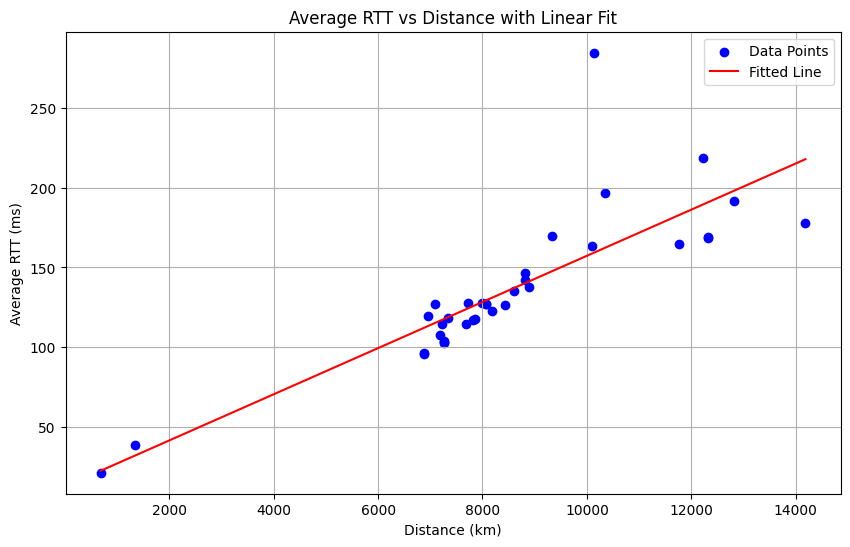

Fitted line equation: y = 0.0145x + 12.7819


In [14]:
import pandas as pd
import urllib.request
import json
import socket
from geopy.distance import distance
from scapy.all import *
import matplotlib.pyplot as plt
import numpy as np


# get the ip of host
self_ip = urllib.request.urlopen('https://api.ipify.org').read().decode('UTF-8')
print("info of host: ")
print('IP: ', self_ip)
# host info
self_info = json.loads(urllib.request.urlopen('http://ip-api.com/json/' + self_ip).read())
print('lat: ', self_info["lat"])
print('lon: ', self_info["lon"])
print('Organization: ', self_info["org"])
print('Location: ', self_info["city"], ',', self_info["country"])
# host location
self_location = (self_info["lat"], self_info["lon"])

# read .csv
df = pd.read_csv('/content/Homework1.csv') # which is from google drive

# store info
dist_time = []

print("\ninfo of server: ")

# traverse each site
for site in df['site']:

    RTT = []
    num_measurements = 10  # times

    # RTT (with TCP)
    for x in range(num_measurements):
        packet = IP(dst=site) / TCP(seq=x)
        ans, unans = sr(packet, verbose=False, timeout=2)
        if ans:  # if response
            rtt = (ans[0][1].time - ans[0][0].sent_time) * 1000  # ms
            RTT.append(rtt)
        else: # no response
            print(f"No response from {site} for measurement {x + 1}")

    # calculate average RTT
    if(len(RTT) == 0):
        print(f"Average RTT for {site} is 0 ms")
        continue # skip this site
    else:
        average_rtt = sum(RTT) / len(RTT)
        print(f"Average RTT for {site}: {average_rtt:.2f} ms")

    # get ip from site
    ip = socket.gethostbyname(site)

    # get info of servers from ip
    url = f'http://ip-api.com/json/{ip}'
    response = urllib.request.urlopen(url)
    ip_info = json.loads(response.read())

    location_info = {
        'site': site,
        'ip': ip,
        'lat': ip_info.get('lat', 'N/A'),
        'lon': ip_info.get('lon', 'N/A'),
        'place': ip_info.get('country', 'N/A')
    }

    print(location_info)
    # server location (using latitude and lontitude)
    site_location = (location_info['lat'], location_info['lon'])

    # measurement distance
    dist = distance(self_location, site_location).km # km
    print(f"Distance between self and target: {dist:.2f} km \n")

    # store average_rtt & dist
    dist_time.append({'site': site, 'average_rtt': average_rtt, 'dist': dist})

# sort (from small to large)
dist_time_sorted = sorted(dist_time, key=lambda x: x['dist'])

# get sorted dist & average_rtt
list_distances = [x['dist'] for x in dist_time_sorted]
list_average_rtts = [x['average_rtt'] for x in dist_time_sorted]

# using numpy.polyfit to fit a line
coefficients = np.polyfit(list_distances, list_average_rtts, 1)
poly = np.poly1d(coefficients)
fit_line = poly(list_distances)

# plot
plt.figure(figsize=(10, 6))
plt.scatter(list_distances, list_average_rtts, color='blue', label='Data Points')
plt.plot(list_distances, fit_line, color='red', label='Fitted Line')
plt.xlabel('Distance (km)')
plt.ylabel('Average RTT (ms)')
plt.title('Average RTT vs Distance with Linear Fit')
plt.grid(True)
plt.legend()

plt.show()

# print the line
print(f"Fitted line equation: y = {coefficients[0]:.4f}x + {coefficients[1]:.4f}")